# From DFM to Star Schema

## Import Libraries

In [41]:
%matplotlib inline

%pip install networkx --quiet

import sys, os, json
from datetime import datetime
from typing import Dict, List, Set

sys.path.insert(0, os.path.abspath(""))

from utils.config import *
from utils.loader import load_tables
from utils.schema_guard import SchemaContract
import networkx as nx
from matplotlib.patches import Patch

os.makedirs(MODELING_REPORT_DIR, exist_ok=True)

Note: you may need to restart the kernel to use updated packages.


## Loading Cleaned Data

In [42]:
dfs = load_tables("cleaned", normalize_cols="lower")

# Register schemas
contract = SchemaContract()
for name, df in dfs.items():
    contract.register(name, df)

print(f"\nRegistered {len(contract.registered_tables)} table schemas.")

pre_report = contract.validate_all(dfs, strict=False)
if pre_report["failures"] == 0:
    print("Pre-schema validation PASSED - cleaned tables match expected schemas.")
else:
    print("Pre-schema validation FAILED - structural issues detected before modeling!")
    for entry in pre_report["details"]:
        if entry["status"] != "PASS":
            print(f"  {entry}")

[Flights] 6,921,847 rows x 18 cols
[Weather_Observations] 1,121,382 rows x 19 cols
[Aircrafts] 6,129 rows x 6 cols
[Carriers] 21 rows x 2 cols
[Stations] 376 rows x 13 cols
[Active_Weather] 3 rows x 2 cols
[Cancellation] 5 rows x 2 cols

Registered 7 table schemas.
Pre-schema validation PASSED - cleaned tables match expected schemas.


## Functional Dependency Discover

In [43]:
def discover_fd(df: pd.DataFrame, min_support: int = 2, exclude_measures: list = None) -> list:
    """Discover functional dependencies X -> Y in a DataFrame."""
    exclude_measures = exclude_measures or []
    fds = []
    for col_a in df.columns:
        if col_a in exclude_measures:
            continue
        if df[col_a].nunique() < min_support:
            continue
        for col_b in df.columns:
            if col_b == col_a or col_b in exclude_measures:
                continue
            max_distinct = df.groupby(col_a)[col_b].nunique().max()
            if max_distinct == 1:
                fds.append((col_a, col_b))
    return fds


print("=== Stations FDs ===")
station_fds = discover_fd(dfs["Stations"], exclude_measures=["latitude", "longitude", "elevation"])
for x, y in station_fds:
    print(f"  {x:<35} -> {y}")

print()
print("=== Aircrafts FDs ===")
aircraft_fds = discover_fd(dfs["Aircrafts"], exclude_measures=["year_of_manufacture"])
for x, y in aircraft_fds:
    print(f"  {x:<35} -> {y}")

print()
print("=== Carriers FDs ===")
carrier_fds = discover_fd(dfs["Carriers"])
for x, y in carrier_fds:
    print(f"  {x:<35} -> {y}")

=== Stations FDs ===
  airport                             -> airport_id
  airport                             -> display_airport_name
  airport                             -> display_airport_city_name_full
  airport                             -> airport_state_name
  airport                             -> airport_state_code
  airport                             -> icao
  airport                             -> iata
  airport                             -> faa
  airport                             -> mesonet_station
  airport_id                          -> airport
  airport_id                          -> display_airport_name
  airport_id                          -> display_airport_city_name_full
  airport_id                          -> airport_state_name
  airport_id                          -> airport_state_code
  airport_id                          -> icao
  airport_id                          -> iata
  airport_id                          -> faa
  airport_id                          -

In [44]:
structural_fds = [
    ("flight_id", "fl_date"),
    ("flight_id", "dep_hour"),
    ("flight_id", "mkt_unique_carrier"),
    ("flight_id", "mkt_carrier_fl_num"),
    ("flight_id", "op_unique_carrier"),
    ("flight_id", "op_carrier_fl_num"),
    ("flight_id", "tail_num"),
    ("flight_id", "origin"),
    ("flight_id", "dest"),
    ("flight_id", "cancelled"),
    ("flight_id", "weather_observation_id"),
    ("flight_id", "dep_time"),
    ("flight_id", "crs_dep_time"),
    ("flight_id", "dep_delay"),
    ("flight_id", "taxi_out"),
    ("flight_id", "air_time"),
    ("flight_id", "distance"),
    ("fl_date", "day_of_week"),
    ("fl_date", "month"),
    ("fl_date", "is_holiday"),
    ("month", "quarter"),
    ("quarter", "year"),
    ("dep_hour", "time_band"),
    ("mkt_unique_carrier", "mkt_carrier_description"),
    ("op_unique_carrier", "op_carrier_description"),
    ("tail_num", "year_of_manufacture"),
    ("tail_num", "manufacturer"),
    ("tail_num", "icao_type"),
    ("tail_num", "range"),
    ("tail_num", "width"),
    ("origin", "origin_airport_id"),
    ("origin", "origin_display_name"),
    ("origin", "origin_city"),
    ("origin", "origin_state_name"),
    ("origin", "origin_state_code"),
    ("origin", "origin_latitude"),
    ("origin", "origin_longitude"),
    ("origin", "origin_elevation"),
    ("origin", "origin_icao"),
    ("origin", "origin_iata"),
    ("origin", "origin_faa"),
    ("origin", "origin_mesonet_station"),
    ("origin_city", "origin_state_name"),
    ("dest", "dest_airport_id"),
    ("dest", "dest_display_name"),
    ("dest", "dest_city"),
    ("dest", "dest_state_name"),
    ("dest", "dest_state_code"),
    ("dest", "dest_latitude"),
    ("dest", "dest_longitude"),
    ("dest", "dest_elevation"),
    ("dest", "dest_icao"),
    ("dest", "dest_iata"),
    ("dest", "dest_faa"),
    ("dest", "dest_mesonet_station"),
    ("dest_city", "dest_state_name"),
    ("cancelled", "cancellation_reason"),
    ("weather_observation_id", "obs_date"),
    ("weather_observation_id", "obs_hour"),
    ("weather_observation_id", "wind_spd"),
    ("weather_observation_id", "wind_gust"),
    ("weather_observation_id", "wind_dir"),
    ("weather_observation_id", "visibility"),
    ("weather_observation_id", "temperature"),
    ("weather_observation_id", "dew_point"),
    ("weather_observation_id", "rel_humidity"),
    ("weather_observation_id", "altimeter"),
    ("weather_observation_id", "cloud_cover"),
    ("weather_observation_id", "lowest_cloud_layer"),
    ("weather_observation_id", "n_cloud_layer"),
    ("weather_observation_id", "low_level_cloud"),
    ("weather_observation_id", "mid_level_cloud"),
    ("weather_observation_id", "high_level_cloud"),
    ("weather_observation_id", "active_weather_status"),
    ("weather_observation_id", "origin_airport"),
    ("active_weather_status", "weather_description"),
    ("origin_airport", "wo_airport_id"),
    ("origin_airport", "wo_display_name"),
    ("origin_airport", "wo_city"),
    ("origin_airport", "wo_state_name"),
    ("origin_airport", "wo_state_code"),
    ("origin_airport", "wo_latitude"),
    ("origin_airport", "wo_longitude"),
    ("origin_airport", "wo_elevation"),
    ("origin_airport", "wo_icao"),
    ("origin_airport", "wo_iata"),
    ("origin_airport", "wo_faa"),
    ("origin_airport", "wo_mesonet_station"),
]

print(f"Total: {len(structural_fds)} structural FDs")

Total: 88 structural FDs


## Choosing The Fact

In [45]:
fact_table = "Flights"
fact_pk = "flight_id"
fact_measures = [
    "dep_delay",
    "taxi_out",
    "air_time",
    "distance",
]

print(f"FACT: {fact_table}")
print(f"  Primary key:  {fact_pk}")
print(f"  Grain:        one row per flight departure (transactional)")
print(f"  Rows:         {len(dfs[fact_table]):,}")
print(f"  Measures ({len(fact_measures)}):")
for m in fact_measures:
    print(f"    - {m}")

FACT: Flights
  Primary key:  flight_id
  Grain:        one row per flight departure (transactional)
  Rows:         6,921,847
  Measures (4):
    - dep_delay
    - taxi_out
    - air_time
    - distance


## Attribute Tree Construction

In [46]:
class AttributeTree:
    """Data-driven attribute tree for DFM modeling."""

    def __init__(self, root: str):
        self.root = root
        self.children: Dict[str, List[str]] = {root: []}
        self.measures: List[str] = []

    def add_fd(self, parent: str, child: str):
        self.children.setdefault(parent, [])
        self.children.setdefault(child, [])
        if child not in self.children[parent]:
            self.children[parent].append(child)

    def add_measure(self, name: str):
        if name not in self.measures:
            self.measures.append(name)

    def all_nodes(self) -> Set[str]:
        return set(self.children.keys())

    def depth(self, node: str = None, visited=None) -> int:
        node = node or self.root
        visited = visited or set()
        if node in visited:
            return 0
        visited.add(node)
        kids = self.children.get(node, [])
        if not kids:
            return 0
        return 1 + max(self.depth(k, visited.copy()) for k in kids)

    def print_tree(self, node: str = None, indent: int = 0, visited=None):
        node = node or self.root
        visited = visited or set()
        if node in visited:
            print("  " * indent + f"(cycle detected: {node})")
            return
        visited.add(node)
        icon = "*" if node == self.root else "-"
        print("  " * indent + f"{icon} {node}")
        for child in self.children.get(node, []):
            self.print_tree(child, indent + 1, visited.copy())
        if node == self.root and self.measures:
            print()
            print("  Measures:")
            for m in self.measures:
                print(f"    [M] {m}")

    def to_dict(self) -> dict:
        return {"root": self.root, "children": self.children, "measures": self.measures, "depth": self.depth(), "n_nodes": len(self.all_nodes())}


tree = AttributeTree(fact_pk)
for x, y in structural_fds:
    tree.add_fd(x, y)
for m in fact_measures:
    tree.add_measure(m)

print("RAW Attribute Tree:")
tree.print_tree()
print(f"\nDepth: {tree.depth()}  |  Nodes: {len(tree.all_nodes())}")

RAW Attribute Tree:
* flight_id
  - fl_date
    - day_of_week
    - month
      - quarter
        - year
    - is_holiday
  - dep_hour
    - time_band
  - mkt_unique_carrier
    - mkt_carrier_description
  - mkt_carrier_fl_num
  - op_unique_carrier
    - op_carrier_description
  - op_carrier_fl_num
  - tail_num
    - year_of_manufacture
    - manufacturer
    - icao_type
    - range
    - width
  - origin
    - origin_airport_id
    - origin_display_name
    - origin_city
      - origin_state_name
    - origin_state_name
    - origin_state_code
    - origin_latitude
    - origin_longitude
    - origin_elevation
    - origin_icao
    - origin_iata
    - origin_faa
    - origin_mesonet_station
  - dest
    - dest_airport_id
    - dest_display_name
    - dest_city
      - dest_state_name
    - dest_state_name
    - dest_state_code
    - dest_latitude
    - dest_longitude
    - dest_elevation
    - dest_icao
    - dest_iata
    - dest_faa
    - dest_mesonet_station
  - cancelled
    - canc

## Visualizing The Attribute Tree

Saved: C:\Users\sider\Desktop\unical\magistrale\I anno\II semestre\data warehouse and visualization\project\output\5-modeling\attribute_tree_raw.png


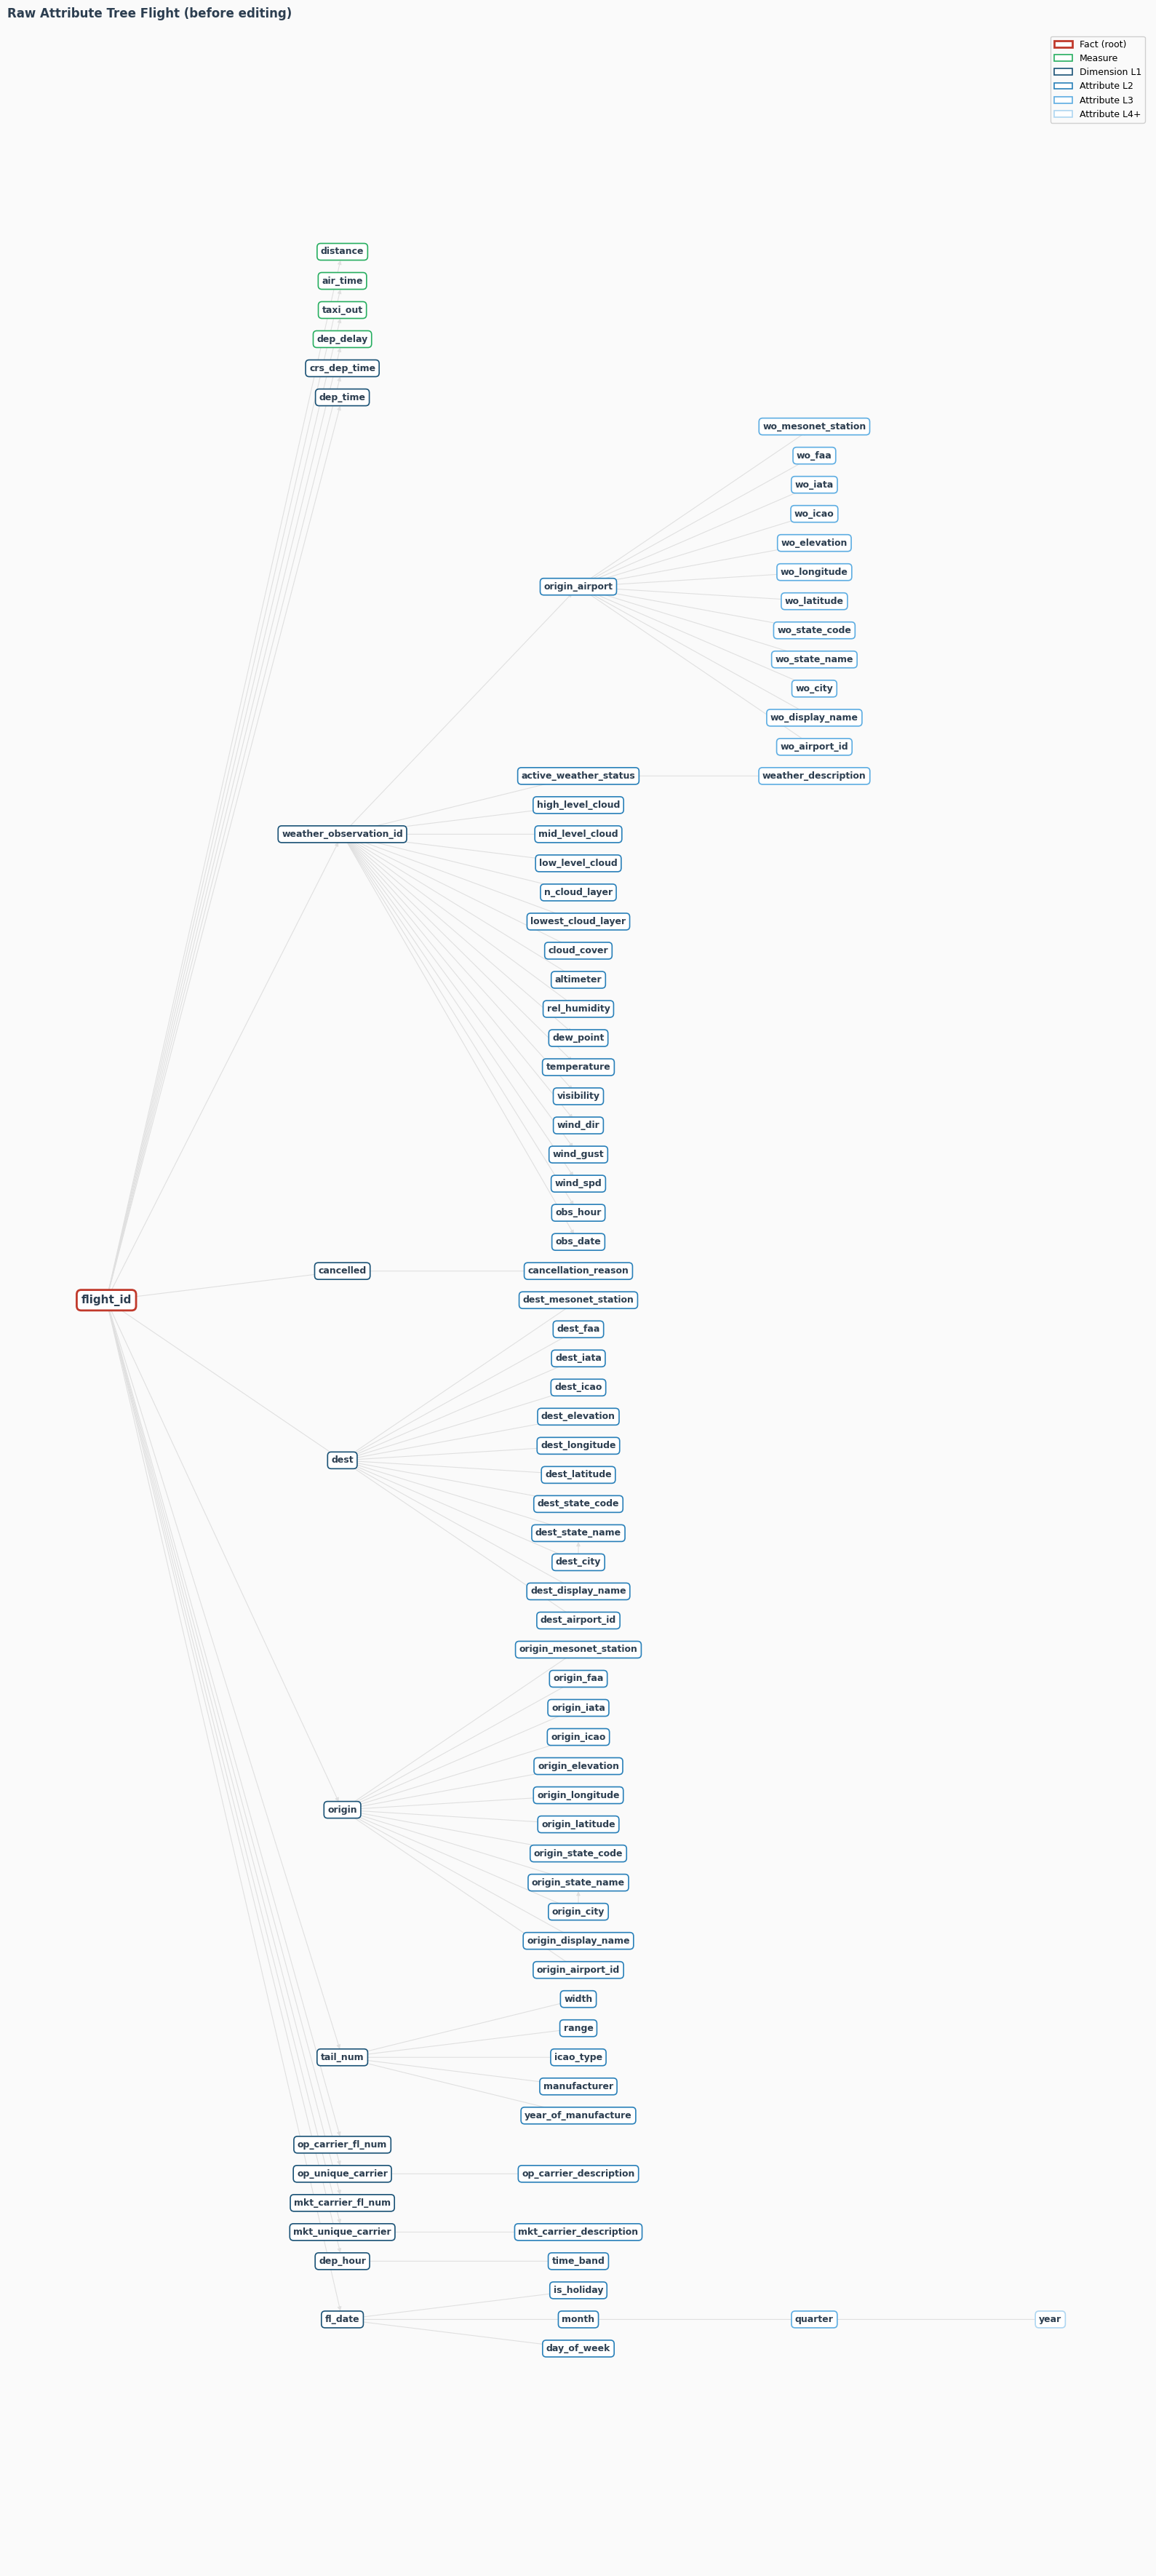

In [47]:
def plot_attribute_tree(tree: AttributeTree, title: str = "Attribute Tree", save_path: str = None, figsize=(16, 9)):
    G = nx.DiGraph()
    for parent, kids in tree.children.items():
        for child in kids:
            G.add_edge(parent, child)
    for m in tree.measures:
        G.add_edge(tree.root, m)

    def count_leaves(node, visited=frozenset()):
        children = [c for c in G.successors(node) if c not in visited]
        if not children:
            return 1
        visited = visited | {node}
        return sum(count_leaves(c, visited) for c in children)

    def _pos(node, y_bottom, y_top, x, visited=frozenset()):
        pos = {node: (x, (y_bottom + y_top) / 2)}
        children = [c for c in G.successors(node) if c not in visited]
        if not children:
            return pos
        visited = visited | {node}
        total_leaves = sum(count_leaves(c, visited) for c in children)
        y = y_bottom
        for child in children:
            share = count_leaves(child, visited) / total_leaves
            child_span = (y_top - y_bottom) * share
            pos.update(_pos(child, y, y + child_span, x + 1, visited))
            y += child_span
        return pos

    pos = _pos(tree.root, 0, 1, 0)

    depth_map = {tree.root: 0}
    for node in nx.bfs_tree(G, tree.root).nodes():
        if nx.has_path(G, tree.root, node):
            depth_map[node] = nx.shortest_path_length(G, tree.root, node)

    DEPTH_COLORS = ["#1A5276", "#2980B9", "#5DADE2", "#AED6F1"]
    measures = set(tree.measures)

    leaves_count = sum(1 for n in G.nodes() if G.out_degree(n) == 0)
    dynamic_width = max(16, tree.depth() * 3.5)
    dynamic_height = max(9, leaves_count * 0.5)
    fig, ax = plt.subplots(figsize=(dynamic_width, dynamic_height))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    nx.draw_networkx_edges(G, pos, edge_color="#E0E0E0", arrows=True, arrowsize=8, width=0.8, ax=ax)

    for node, (x, y) in pos.items():
        is_root = node == tree.root
        is_measure = node in measures
        if is_root:
            color = "#C0392B"
        elif is_measure:
            color = "#27AE60"
        else:
            depth = depth_map.get(node, len(DEPTH_COLORS))
            color = DEPTH_COLORS[min(depth - 1, len(DEPTH_COLORS) - 1)]  # BUG FIX: was DEPTH_COLORSin(...)
        lw = 2.0 if is_root else 1.2
        fs = 11 if is_root else 9
        ax.text(
            x,
            y,
            node,
            ha="center",
            va="center",
            fontsize=fs,
            color="#2C3E50",
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.4", linewidth=lw),
            zorder=3,
            clip_on=True,
        )

    legend_items = [
        Patch(facecolor="white", edgecolor="#C0392B", linewidth=2, label="Fact (root)"),
        Patch(facecolor="white", edgecolor="#27AE60", linewidth=1.2, label="Measure"),
        Patch(facecolor="white", edgecolor="#1A5276", linewidth=1.2, label="Dimension L1"),
        Patch(facecolor="white", edgecolor="#2980B9", linewidth=1.2, label="Attribute L2"),
        Patch(facecolor="white", edgecolor="#5DADE2", linewidth=1.2, label="Attribute L3"),
        Patch(facecolor="white", edgecolor="#AED6F1", linewidth=1.2, label="Attribute L4+"),
    ]
    ax.legend(handles=legend_items, loc="upper right", fontsize=9, framealpha=0.9, edgecolor="#CCCCCC")
    ax.set_title(title, fontsize=12, fontweight="bold", color="#2C3E50", pad=14, loc="left")
    ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()


plot_attribute_tree(tree, title="Raw Attribute Tree Flight (before editing)", save_path=MODELING_REPORT_DIR / "attribute_tree_raw.png")

## Attribute Tree Editing

Tree after pruning & grafting:
* flight_id
  - fl_date
    - day_of_week
    - month
      - quarter
        - year
    - is_holiday
  - dep_hour
    - time_band
  - tail_num
    - manufacturer
    - aircraft_age
  - origin
    - origin_display_name
    - origin_city
      - origin_state_name
    - origin_latitude
    - origin_longitude
  - dest
    - dest_display_name
    - dest_city
      - dest_state_name
    - dest_latitude
    - dest_longitude
  - dep_delay
  - taxi_out
  - air_time
  - distance
  - mkt_carrier_description
  - op_carrier_description
  - cancellation_reason
  - wind_spd
  - wind_gust
  - visibility
  - temperature
  - cloud_cover
  - weather_description

  Measures:
    [M] dep_delay
    [M] taxi_out
    [M] air_time
    [M] distance
    [M] wind_spd
    [M] wind_gust
    [M] visibility
    [M] temperature
    [M] cloud_cover
Saved: C:\Users\sider\Desktop\unical\magistrale\I anno\II semestre\data warehouse and visualization\project\output\5-modeling\attribute_tree_

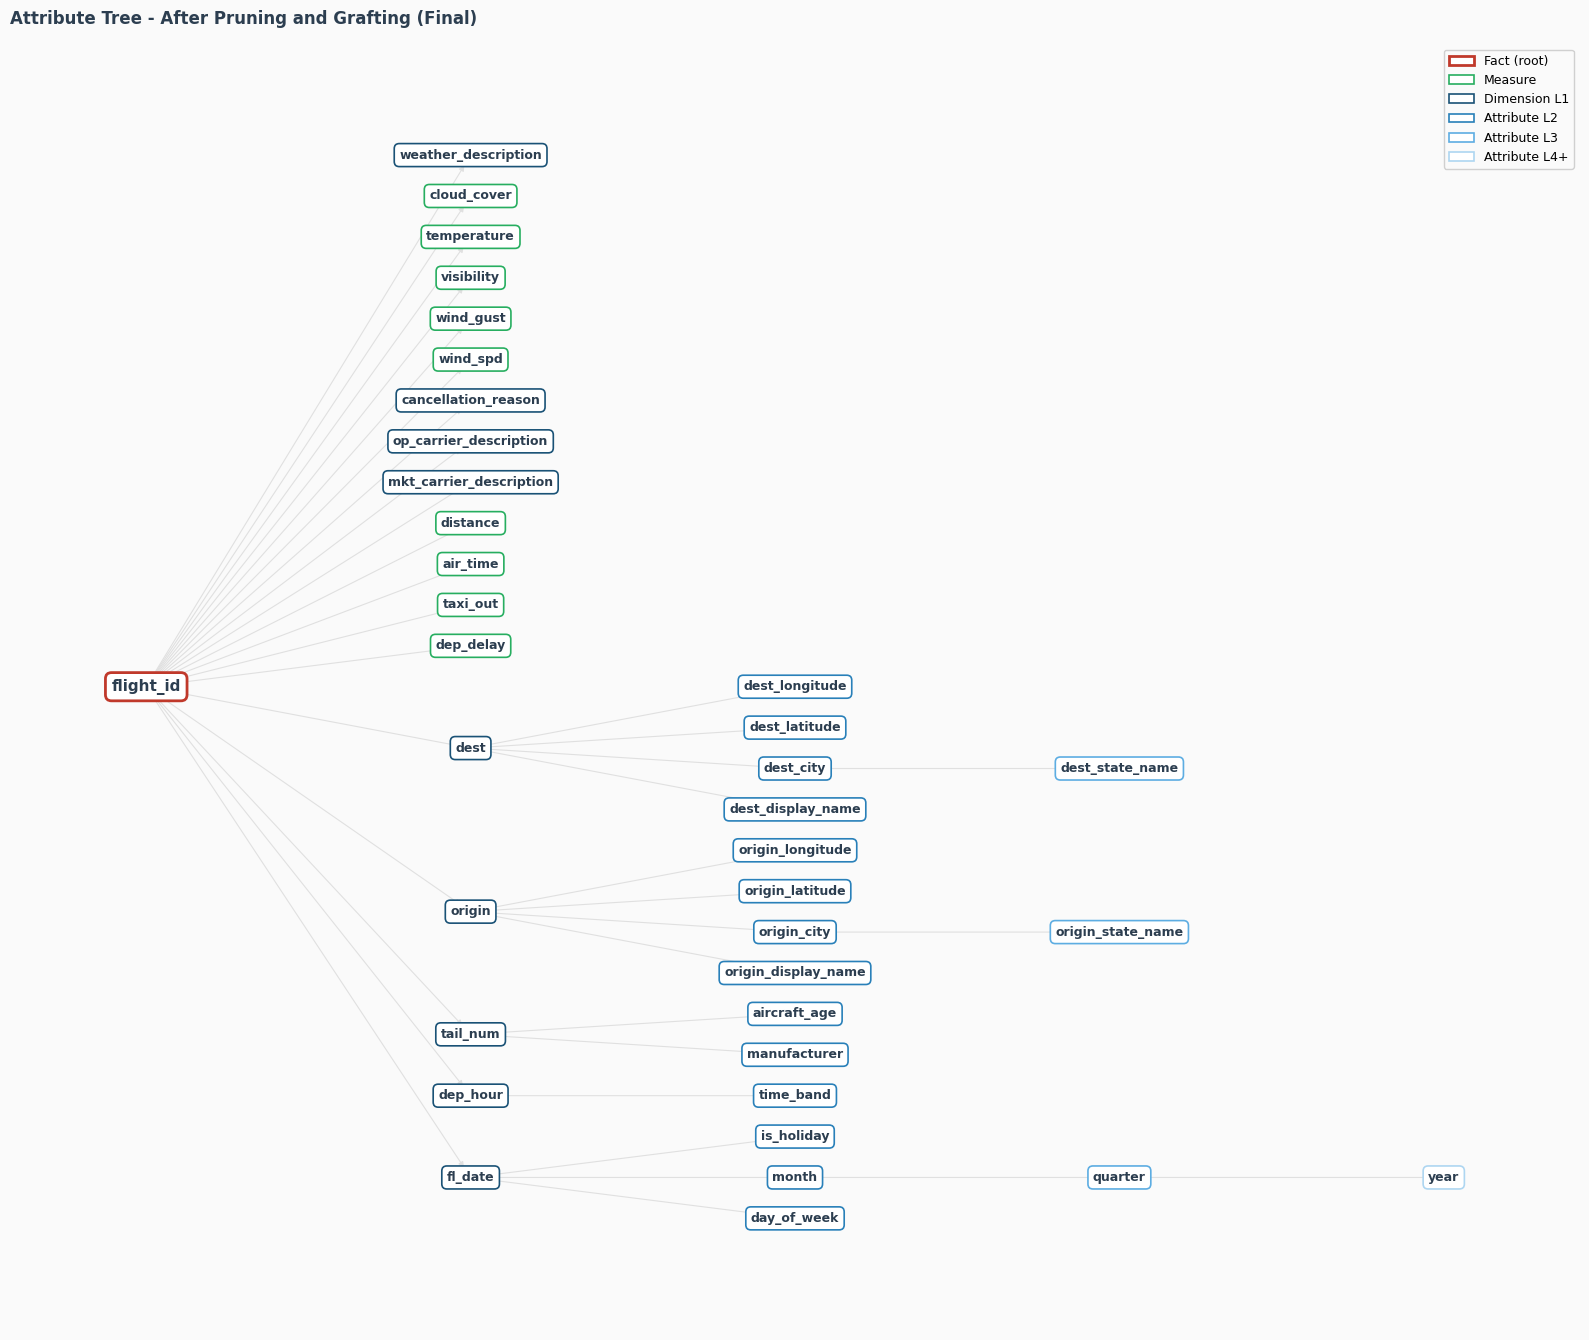

In [56]:
def prune(tree: AttributeTree, nodes_to_prune: list):
    removed = set()
    for node in nodes_to_prune:
        if node not in tree.children:
            continue
        children = tree.children.get(node, [])
        for parent in list(tree.children.keys()):
            if node in tree.children[parent]:
                tree.children[parent].remove(node)
                for c in children:
                    if c not in tree.children[parent]:
                        tree.children[parent].append(c)
        tree.children.pop(node, None)
        removed.add(node)
    return removed


def graft(tree, node: str):
    if node == getattr(tree, "root", None):
        return
    parent = None
    for p, kids in list(tree.children.items()):
        if node in kids:
            parent = p
            break
    if not parent:
        return
    children_to_move = tree.children.get(node, [])
    for child in children_to_move:
        if child not in tree.children.get(parent, []):
            tree.add_fd(parent, child)
    tree.children[parent].remove(node)
    if not tree.children[parent]:
        del tree.children[parent]
    if node in tree.children:
        del tree.children[node]


pruned_nodes = prune(
    tree,
    [
        "mkt_carrier_fl_num",
        "op_carrier_fl_num",
        "dep_time",
        "crs_dep_time",
        "icao_type",
        "range",
        "width",
        "year_of_manufacture",
        "origin_airport_id",
        "origin_state_code",
        "origin_elevation",
        "origin_icao",
        "origin_iata",
        "origin_faa",
        "origin_mesonet_station",
        "dest_airport_id",
        "dest_state_code",
        "dest_elevation",
        "dest_icao",
        "dest_iata",
        "dest_faa",
        "dest_mesonet_station",
        "obs_date",
        "obs_hour",
        "wind_dir",
        "dew_point",
        "rel_humidity",
        "altimeter",
        "lowest_cloud_layer",
        "n_cloud_layer",
        "low_level_cloud",
        "mid_level_cloud",
        "high_level_cloud",
        "origin_airport",
        "wo_airport_id",
        "wo_display_name",
        "wo_city",
        "wo_state_name",
        "wo_state_code",
        "wo_latitude",
        "wo_longitude",
        "wo_elevation",
        "wo_icao",
        "wo_iata",
        "wo_faa",
        "wo_mesonet_station",
    ],
)

for parent, child in [("origin", "origin_state_name"), ("dest", "dest_state_name")]:
    if child in tree.children.get(parent, []):
        tree.children[parent].remove(child)

tree.add_fd("tail_num", "aircraft_age")

for n in ["mkt_unique_carrier", "op_unique_carrier", "cancelled", "weather_observation_id", "active_weather_status"]:
    graft(tree, n)

updated_measures = [
    "dep_delay",
    "taxi_out",
    "air_time",
    "distance",
    "wind_spd",
    "wind_gust",
    "visibility",
    "temperature",
    "cloud_cover",
]

for m in updated_measures:
    if m not in tree.measures:
        tree.add_measure(m)

print("Tree after pruning & grafting:")
tree.print_tree()
plot_attribute_tree(tree, title="Attribute Tree - After Pruning and Grafting (Final)", save_path=MODELING_REPORT_DIR / "attribute_tree_edited.png")

## Measures and Additivity

In [49]:
MEASURE_ADDITIVITY = {
    "dep_delay": "additive",
    "taxi_out": "additive",
    "air_time": "additive",
    "distance": "semi_additive",
    "wind_spd": "non_additive",
    "wind_gust": "non_additive",
    "visibility": "non_additive",
    "temperature": "non_additive",
    "cloud_cover": "non_additive",
}

MEASURE_VALID_AGGS = {
    "dep_delay": ["SUM", "AVG", "MIN", "MAX"],
    "taxi_out": ["SUM", "AVG", "MIN", "MAX"],
    "air_time": ["SUM", "AVG", "MIN", "MAX"],
    "distance": ["AVG", "MIN", "MAX"],
    "wind_spd": ["AVG", "MAX"],
    "wind_gust": ["MAX", "AVG"],
    "visibility": ["MIN", "AVG"],
    "temperature": ["AVG", "MIN", "MAX"],
    "cloud_cover": ["AVG", "MAX"],
}

icon = {"additive": "[A]", "semi_additive": "[S]", "non_additive": "[N]"}
for m, a in MEASURE_ADDITIVITY.items():
    print(f"  {icon[a]}  {m:<18} {a:<14}  valid: {MEASURE_VALID_AGGS[m]}")

  [A]  dep_delay          additive        valid: ['SUM', 'AVG', 'MIN', 'MAX']
  [A]  taxi_out           additive        valid: ['SUM', 'AVG', 'MIN', 'MAX']
  [A]  air_time           additive        valid: ['SUM', 'AVG', 'MIN', 'MAX']
  [S]  distance           semi_additive   valid: ['AVG', 'MIN', 'MAX']
  [N]  wind_spd           non_additive    valid: ['AVG', 'MAX']
  [N]  wind_gust          non_additive    valid: ['MAX', 'AVG']
  [N]  visibility         non_additive    valid: ['MIN', 'AVG']
  [N]  temperature        non_additive    valid: ['AVG', 'MIN', 'MAX']
  [N]  cloud_cover        non_additive    valid: ['AVG', 'MAX']


## DFM Schema

In [57]:
def to_dfm_text(tree: AttributeTree) -> str:
    lines = []
    width = 52
    lines.append("+" + "=" * width + "+")
    lines.append(f'|  FACT: {"FLIGHT":<{width-8}}|')
    lines.append(f"|  Grain: one row per flight (transactional)         |")
    lines.append("|" + " " * width + "|")
    add_icon = {"additive": "[A]", "semi_additive": "[S]", "non_additive": "[N]"}
    for m in tree.measures:
        a = MEASURE_ADDITIVITY.get(m, "?")
        lines.append(f'|    {add_icon.get(a,"[ ]")} {m:<{width-8}}|')
    lines.append("+" + "=" * width + "+")
    lines.append("")
    lines.append("Legend: [A]=additive  [S]=semi-additive  [N]=non-additive")
    lines.append("")
    lines.append("Dimensions and Hierarchies (. = hierarchy level):")
    lines.append("")

    def traverse(node, depth=1):
        for child in tree.children.get(node, []):
            indent = "   " + "  " * (depth - 1)
            lines.append(f"{indent}. {child}")
            traverse(child, depth + 1)

    for dim in tree.children.get(tree.root, []):
        lines.append(f"   . {dim}")
        traverse(dim, depth=2)
    return "\n".join(lines)


dfm_text = to_dfm_text(tree)
print(dfm_text)
with open(MODELING_REPORT_DIR / "DFM_text.txt", "w") as f:
    f.write(dfm_text)

+====================================================+
|  FACT: FLIGHT                                      |
|  Grain: one row per flight (transactional)         |
|                                                    |
|    [A] dep_delay                                   |
|    [A] taxi_out                                    |
|    [A] air_time                                    |
|    [S] distance                                    |
|    [N] wind_spd                                    |
|    [N] wind_gust                                   |
|    [N] visibility                                  |
|    [N] temperature                                 |
|    [N] cloud_cover                                 |
+====================================================+

Legend: [A]=additive  [S]=semi-additive  [N]=non-additive

Dimensions and Hierarchies (. = hierarchy level):

   . fl_date
     . day_of_week
     . month
       . quarter
         . year
     . is_holiday
   . dep_hour
     . ti

## Star Schema

In [58]:
def build_star_schema(tree: AttributeTree) -> dict:
    star = {
        "fact_table": {"name": "FLIGHTS", "grain": "one row per flight departure (transactional)", "measures": tree.measures, "foreign_keys": []},
        "dimension_tables": {},
    }
    star["dimension_tables"]["DIM_FL_DATES"] = {
        "surrogate_key": "FL_DATE_ID",
        "natural_key": "FL_DATE",
        "levels": ["FL_DATE", "DAY_OF_WEEK", "IS_HOLIDAY", "MONTH", "QUARTER", "YEAR"],
        "col_types": {"FL_DATE": "DATE NOT NULL", "DAY_OF_WEEK": "VARCHAR(10)", "IS_HOLIDAY": "BOOLEAN", "MONTH": "SMALLINT", "QUARTER": "SMALLINT", "YEAR": "SMALLINT"},
        "description": "Calendar date dimension with holiday flag",
        "fk_on_fact": "FL_DATE_ID",
    }
    star["fact_table"]["foreign_keys"].append(("FL_DATE_ID", "DIM_FL_DATES"))
    star["dimension_tables"]["DIM_DEP_HOURS"] = {
        "surrogate_key": "DEP_HOUR_ID",
        "natural_key": "DEP_HOUR",
        "levels": ["DEP_HOUR", "TIME_BAND"],
        "col_types": {"DEP_HOUR": "SMALLINT", "TIME_BAND": "VARCHAR(20)"},
        "description": "Hour-of-day dimension with time band",
        "fk_on_fact": "DEP_HOUR_ID",
    }
    star["fact_table"]["foreign_keys"].append(("DEP_HOUR_ID", "DIM_DEP_HOURS"))
    star["dimension_tables"]["DIM_STATIONS"] = {
        "surrogate_key": "STATION_ID",
        "natural_key": "AIRPORT_CODE",
        "levels": ["AIRPORT_CODE", "AIRPORT_NAME", "CITY", "STATE", "LATITUDE", "LONGITUDE"],
        "col_types": {"AIRPORT_CODE": "CHAR(4) NOT NULL", "AIRPORT_NAME": "VARCHAR(150)", "CITY": "VARCHAR(100)", "STATE": "VARCHAR(50)", "LATITUDE": "NUMERIC(9,6)", "LONGITUDE": "NUMERIC(9,6)"},
        "description": "Airport dimension - role-playing: Origin_Station_ID and Dest_Station_ID",
        "fk_on_fact": ["ORIGIN_STATION_ID", "DEST_STATION_ID"],
    }
    star["fact_table"]["foreign_keys"].append(("ORIGIN_STATION_ID", "DIM_STATIONS"))
    star["fact_table"]["foreign_keys"].append(("DEST_STATION_ID", "DIM_STATIONS"))
    star["dimension_tables"]["DIM_CARRIERS"] = {
        "surrogate_key": "CARRIER_ID",
        "natural_key": "DESCRIPTION",
        "levels": ["DESCRIPTION"],
        "col_types": {"DESCRIPTION": "VARCHAR(100) NOT NULL"},
        "description": "Carrier dimension - role-playing: MKT_Carrier_ID and OP_Carrier_ID",
        "fk_on_fact": ["MKT_CARRIER_ID", "OP_CARRIER_ID"],
    }
    star["fact_table"]["foreign_keys"].append(("MKT_CARRIER_ID", "DIM_CARRIERS"))
    star["fact_table"]["foreign_keys"].append(("OP_CARRIER_ID", "DIM_CARRIERS"))
    star["dimension_tables"]["DIM_AIRCRAFTS"] = {
        "surrogate_key": "AIRCRAFT_ID",
        "natural_key": "TAIL_NUM",
        "levels": ["TAIL_NUM", "MANUFACTURER", "AIRCRAFT_AGE"],
        "col_types": {"TAIL_NUM": "CHAR(10) NOT NULL", "MANUFACTURER": "VARCHAR(50)", "AIRCRAFT_AGE": "SMALLINT"},
        "description": "Aircraft dimension with registration, manufacturer, and age at flight reference year",
        "fk_on_fact": "AIRCRAFT_ID",
    }
    star["fact_table"]["foreign_keys"].append(("AIRCRAFT_ID", "DIM_AIRCRAFTS"))
    star["dimension_tables"]["DIM_JUNK"] = {
        "surrogate_key": "JUNK_ID",
        "natural_key": None,
        "levels": ["CANCELLATION_REASON", "WEATHER_DESCRIPTION"],
        "col_types": {"CANCELLATION_REASON": "VARCHAR(60)", "WEATHER_DESCRIPTION": "VARCHAR(150)"},
        "description": "Junk dimension: low-cardinality flags",
        "fk_on_fact": "JUNK_ID",
    }
    star["fact_table"]["foreign_keys"].append(("JUNK_ID", "DIM_JUNK"))
    return star


star_schema = build_star_schema(tree)
print(f'FACT: {star_schema["fact_table"]["name"]}')
print(f'  Dimensions: {list(star_schema["dimension_tables"].keys())}')
print(f'  Measures: {star_schema["fact_table"]["measures"]}')
print(f'  FKs: {[fk for fk, _ in star_schema["fact_table"]["foreign_keys"]]}')

FACT: FLIGHTS
  Dimensions: ['DIM_FL_DATES', 'DIM_DEP_HOURS', 'DIM_STATIONS', 'DIM_CARRIERS', 'DIM_AIRCRAFTS', 'DIM_JUNK']
  Measures: ['dep_delay', 'taxi_out', 'air_time', 'distance', 'wind_spd', 'wind_gust', 'visibility', 'temperature', 'cloud_cover']
  FKs: ['FL_DATE_ID', 'DEP_HOUR_ID', 'ORIGIN_STATION_ID', 'DEST_STATION_ID', 'MKT_CARRIER_ID', 'OP_CARRIER_ID', 'AIRCRAFT_ID', 'JUNK_ID']


## SQL DDL Generation

In [59]:
def generate_ddl(star: dict, measure_additivity: dict) -> str:
    def pretty_col(name: str) -> str:
        return name.upper()

    lines = []
    lines.append("-- ============================================================")
    lines.append("--  DATA WAREHOUSE - Star Schema")
    lines.append("--  PostgreSQL DDL")
    lines.append(f"--  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    lines.append("-- ============================================================")
    lines.append("")
    dims = star["dimension_tables"]
    dim_order = ["DIM_FL_DATES", "DIM_DEP_HOURS", "DIM_STATIONS", "DIM_CARRIERS", "DIM_AIRCRAFTS", "DIM_JUNK"]
    for i, dname in enumerate(dim_order, 1):
        meta = dims[dname]
        lines.append(f"CREATE TABLE IF NOT EXISTS {dname} (")
        col_lines = [f"    {meta['surrogate_key']}  SERIAL      PRIMARY KEY,"]
        for col in meta["levels"]:
            dtype = meta["col_types"].get(col, "VARCHAR(100)")
            col_lines.append(f"    {col:<30} {dtype},")
        col_lines.append("    LOAD_TIMESTAMP                 TIMESTAMP DEFAULT CURRENT_TIMESTAMP")
        lines.append("\n".join(col_lines))
        lines.append(");\n")
    fact = star["fact_table"]
    lines.append(f"CREATE TABLE IF NOT EXISTS {fact['name']} (")
    col_lines = ["    FLIGHT_ID           SERIAL       PRIMARY KEY,"]
    for fk_col, ref_table in fact["foreign_keys"]:
        not_null = "NOT NULL" if ref_table in ("DIM_FL_DATES", "DIM_DEP_HOURS", "DIM_STATIONS", "DIM_CARRIERS", "DIM_AIRCRAFTS", "DIM_JUNK") else "        "
        col_lines.append(f"    {fk_col:<24} INTEGER      {not_null} REFERENCES {ref_table}({dims[ref_table]['surrogate_key']}),")
    measure_dtypes = {
        "dep_delay": "NUMERIC(6,1)",
        "taxi_out": "NUMERIC(6,1)",
        "air_time": "NUMERIC(6,1)",
        "distance": "NUMERIC(7,1)",
        "wind_spd": "NUMERIC(5,1)",
        "wind_gust": "NUMERIC(5,1)",
        "visibility": "NUMERIC(5,1)",
        "temperature": "NUMERIC(5,2)",
        "cloud_cover": "NUMERIC(5,1)",
    }
    env_measures = ["wind_spd", "wind_gust", "visibility", "temperature", "cloud_cover"]
    perf_measures = ["dep_delay", "taxi_out", "air_time", "distance"]
    for m in env_measures:
        col_lines.append(f"    {pretty_col(m):<24} {measure_dtypes.get(m, 'NUMERIC(8,2)')},")
    for m in perf_measures:
        col_lines.append(f"    {pretty_col(m):<24} {measure_dtypes.get(m, 'NUMERIC(8,2)')},")
    col_lines.append("    LOAD_TIMESTAMP           TIMESTAMP DEFAULT CURRENT_TIMESTAMP")
    lines.append("\n".join(col_lines))
    lines.append(");\n")
    for suffix, col in [
        ("DATE", "FL_DATE_ID"),
        ("HOUR", "DEP_HOUR_ID"),
        ("ORIGIN", "ORIGIN_STATION_ID"),
        ("DEST", "DEST_STATION_ID"),
        ("MKT", "MKT_CARRIER_ID"),
        ("OP", "OP_CARRIER_ID"),
        ("AIRCRAFT", "AIRCRAFT_ID"),
        ("JUNK", "JUNK_ID"),
    ]:
        lines.append(f"CREATE INDEX IF NOT EXISTS IDX_FLIGHTS_{suffix:<8} ON {fact['name']}({col});")
    return "\n".join(lines)


ddl_sql = generate_ddl(star_schema, MEASURE_ADDITIVITY)
print(ddl_sql)
with open(MODELING_REPORT_DIR / "dw_schema_generated.sql", "w") as f:
    f.write(ddl_sql)

-- ============================================================
--  DATA WAREHOUSE - Star Schema
--  PostgreSQL DDL
--  Generated: 2026-05-24 19:02:55
-- ============================================================

CREATE TABLE IF NOT EXISTS DIM_FL_DATES (
    FL_DATE_ID  SERIAL      PRIMARY KEY,
    FL_DATE                        DATE NOT NULL,
    DAY_OF_WEEK                    VARCHAR(10),
    IS_HOLIDAY                     BOOLEAN,
    MONTH                          SMALLINT,
    QUARTER                        SMALLINT,
    YEAR                           SMALLINT,
    LOAD_TIMESTAMP                 TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS DIM_DEP_HOURS (
    DEP_HOUR_ID  SERIAL      PRIMARY KEY,
    DEP_HOUR                       SMALLINT,
    TIME_BAND                      VARCHAR(20),
    LOAD_TIMESTAMP                 TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

CREATE TABLE IF NOT EXISTS DIM_STATIONS (
    STATION_ID  SERIAL      PRIMARY KEY,
    AIRPORT_C

## Glossary

In [60]:
glossary = [
    {"measure": "# of flights", "definition": "Total number of flight departures.", "unit": "count", "computation": "COUNT(*)", "additivity": "additive", "valid_aggregations": ["COUNT"]},
    {"measure": "avg_delay", "definition": "Average departure delay.", "unit": "minutes", "computation": "AVG(Dep_Delay)", "additivity": "non_additive", "valid_aggregations": ["AVG"]},
    {"measure": "sum_delay", "definition": "Total departure delay minutes.", "unit": "minutes", "computation": "SUM(Dep_Delay)", "additivity": "additive", "valid_aggregations": ["SUM"]},
    {"measure": "max_delay", "definition": "Maximum single departure delay.", "unit": "minutes", "computation": "MAX(Dep_Delay)", "additivity": "non_additive", "valid_aggregations": ["MAX"]},
    {"measure": "avg_taxi_out", "definition": "Average gate-to-runway time.", "unit": "minutes", "computation": "AVG(Taxi_Out)", "additivity": "non_additive", "valid_aggregations": ["AVG"]},
    {"measure": "avg_air_time", "definition": "Average airborne time.", "unit": "minutes", "computation": "AVG(Air_Time)", "additivity": "non_additive", "valid_aggregations": ["AVG"]},
    {
        "measure": "avg_distance",
        "definition": "Average route distance. Semi-additive.",
        "unit": "statute miles",
        "computation": "AVG(Distance)",
        "additivity": "semi_additive",
        "valid_aggregations": ["AVG"],
    },
    {"measure": "avg_wind_spd", "definition": "Average sustained wind speed at origin.", "unit": "knots", "computation": "AVG(Wind_Spd)", "additivity": "non_additive", "valid_aggregations": ["AVG"]},
    {"measure": "max_wind_gust", "definition": "Maximum wind gust at origin.", "unit": "knots", "computation": "MAX(Wind_Gust)", "additivity": "non_additive", "valid_aggregations": ["MAX"]},
    {
        "measure": "min_visibility",
        "definition": "Minimum visibility at origin.",
        "unit": "statute miles",
        "computation": "MIN(Visibility)",
        "additivity": "non_additive",
        "valid_aggregations": ["MIN"],
    },
    {"measure": "avg_temperature", "definition": "Average temperature at origin.", "unit": "Celsius", "computation": "AVG(Temperature)", "additivity": "non_additive", "valid_aggregations": ["AVG"]},
    {
        "measure": "min_temperature",
        "definition": "Minimum temperature at origin.",
        "unit": "Celsius",
        "computation": "MIN(Temperature)",
        "additivity": "non_additive",
        "valid_aggregations": ["MIN"],
    },
    {
        "measure": "avg_cloud_cover",
        "definition": "Average cloud cover index (0-4).",
        "unit": "ordinal 0-4",
        "computation": "AVG(Cloud_Cover)",
        "additivity": "non_additive",
        "valid_aggregations": ["AVG"],
    },
]

pd.DataFrame(glossary).to_csv(MODELING_REPORT_DIR / "glossary_measures.csv", index=False)

## Export Schema

In [61]:
schema_export = {
    "generated_at": datetime.now().isoformat(),
    "fact": fact_table,
    "fact_pk": fact_pk,
    "grain": "one row per flight departure (transactional)",
    "reconciled_db": {"tables": list(dfs.keys()), "location": CLEANED_DATA_DIR},
    "attribute_tree": tree.to_dict(),
    "measures": {"definitions": MEASURE_ADDITIVITY, "valid_aggs": MEASURE_VALID_AGGS},
    "star_schema": star_schema,
    "glossary": glossary,
}
with open(MODELING_REPORT_DIR / "schema.json", "w") as f:
    json.dump(schema_export, f, indent=2, default=str)

print(f'Exported schema.json - Dimensions: {len(star_schema["dimension_tables"])}, Measures: {len(star_schema["fact_table"]["measures"])}')

Exported schema.json - Dimensions: 6, Measures: 9


## Post-Schema Validation

In [62]:
# Validate tables against original schemas
report = contract.validate_all(dfs, strict=False)
if report["failures"] == 0:
    print("Schema validation PASSED - all tables match expected schemas.")
else:
    print("Schema validation FAILED - structural changes detected!")
    for entry in report["details"]:
        if entry["status"] != "PASS":
            print(f"  {entry}")

Schema validation PASSED - all tables match expected schemas.
